# Adverse Selection Detection — MLB Game Markets (KXMLBGAME)

**Applying Dalen (2025) RN-JD calibration to Kalshi baseball game winner markets**

Reference: *Toward Black-Scholes for Prediction Markets* (arXiv:2510.15205)

---

### Why Sports?
Game outcomes are **news-driven**: scores update in real time, and prices jump when
runs are scored or key events occur. Live bettors may have information advantages
(streaming delay, faster data). Each game is a binary market (Team A wins / Team B wins)
with high volume on playoff and marquee matchups.

**To fetch more data:** run `python scripts/fetch_mlb_election.py` from the project root.

### Structure
1. Data loading
2. RN-JD calibration
3. AS detection showcase
4. Fill toxicity validation
5. Market-making backtest
6. Threshold sweep
7. Summary


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats as sp_stats

from src.as_detector import run_as_detection, run_all_tickers, ASResult
from src.mm_backtest import (
    compare_strategies, compare_all_tickers,
    sweep_thresholds, backtest_mm, analyse_fill_toxicity,
)

plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})

import glob
CACHE = os.path.join('..', 'cache', 'kalshi_hf_mlb')
all_files = sorted(glob.glob(os.path.join(CACHE, '*_trades.parquet')))
print(f"Found {len(all_files)} parquet files")

data = {}
for f in all_files:
    tkr = os.path.basename(f).replace("_trades.parquet", "")
    df = pd.read_parquet(f).sort_values("timestamp").reset_index(drop=True)
    if len(df) >= 250:
        data[tkr] = df

data = dict(sorted(data.items(), key=lambda x: -len(x[1])))
print(f"Loaded {len(data)} tickers with >= 250 trades")
print(f"Total trades: {sum(len(v) for v in data.values()):,}")
for tkr, df in list(data.items())[:15]:
    print(f"  {tkr:<45s}  {len(df):>6,} trades  [{df['mid_price'].min():.2f} - {df['mid_price'].max():.2f}]")
if len(data) > 15:
    print(f"  ... and {len(data) - 15} more tickers")

if len(data) == 0:
    print("\nNo data. Run: python scripts/fetch_mlb_election.py")

Found 40 parquet files
Loaded 40 tickers with >= 250 trades
Total trades: 714,486
  KXMLBGAME-25OCT27TORLAD-LAD                    52,362 trades  [0.30 - 0.99]
  KXMLBGAME-25OCT27TORLAD-TOR                    44,406 trades  [0.01 - 0.70]
  KXMLBGAME-25OCT24LADTOR-LAD                    37,784 trades  [0.01 - 0.81]
  KXMLBGAME-25OCT28TORLAD-LAD                    29,600 trades  [0.01 - 0.75]
  KXMLBGAME-25OCT31LADTOR-TOR                    28,911 trades  [0.01 - 0.74]
  KXMLBGAME-25OCT31LADTOR-LAD                    25,872 trades  [0.50 - 0.99]
  KXMLBGAME-25OCT29TORLAD-LAD                    25,114 trades  [0.01 - 0.73]
  KXMLBGAME-25OCT15TORSEA-SEA                    20,621 trades  [0.01 - 0.83]
  KXMLBGAME-25OCT29TORLAD-TOR                    20,537 trades  [0.30 - 0.99]
  KXMLBGAME-25OCT19SEATOR-SEA                    20,047 trades  [0.01 - 0.73]
  KXMLBGAME-25OCT28TORLAD-TOR                    19,787 trades  [0.21 - 0.99]
  KXMLBGAME-25OCT09PHILAD-LAD                    19,544 trad

## 2. RN-JD Calibration

In [9]:
all_as = run_all_tickers(data, em_window=200, em_iterations=8)
print(f"Calibrated {len(all_as)} tickers")

if all_as:
    cal_rows = [ar.calibration_summary for tkr, ar in sorted(all_as.items(), key=lambda x: -len(x[1].prices))]
    cal_df = pd.DataFrame(cal_rows)
    cols = ["ticker", "n_trades", "mean_sigma_b", "mean_lambda", "n_jumps_detected", "n_bursts_detected", "pct_flagged"]
    print(cal_df[cols].to_string(index=False, float_format="%.5f"))

[2026-03-03 03:49:51 UTC] [INFO] tauroi.as_detector — AS detection KXMLBGAME-25OCT27TORLAD-LAD: 52362 trades, 1157 jumps (γ>0.5), 5483 bursts, 1085 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.00574
[2026-03-03 03:50:03 UTC] [INFO] tauroi.as_detector — AS detection KXMLBGAME-25OCT27TORLAD-TOR: 44406 trades, 1585 jumps (γ>0.5), 5012 bursts, 1475 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.01023
[2026-03-03 03:50:12 UTC] [INFO] tauroi.as_detector — AS detection KXMLBGAME-25OCT24LADTOR-LAD: 37784 trades, 400 jumps (γ>0.5), 2321 bursts, 358 flagged (score>0.5), mean σ_b=0.0002, mean λ=0.00209
[2026-03-03 03:50:18 UTC] [INFO] tauroi.as_detector — AS detection KXMLBGAME-25OCT28TORLAD-LAD: 29600 trades, 584 jumps (γ>0.5), 2662 bursts, 545 flagged (score>0.5), mean σ_b=0.0002, mean λ=0.00272
[2026-03-03 03:50:24 UTC] [INFO] tauroi.as_detector — AS detection KXMLBGAME-25OCT31LADTOR-TOR: 28911 trades, 518 jumps (γ>0.5), 2023 bursts, 489 flagged (score>0.5), mean σ_b=0.0001, mean λ=0.00352
[

## 3. AS Detection Showcase

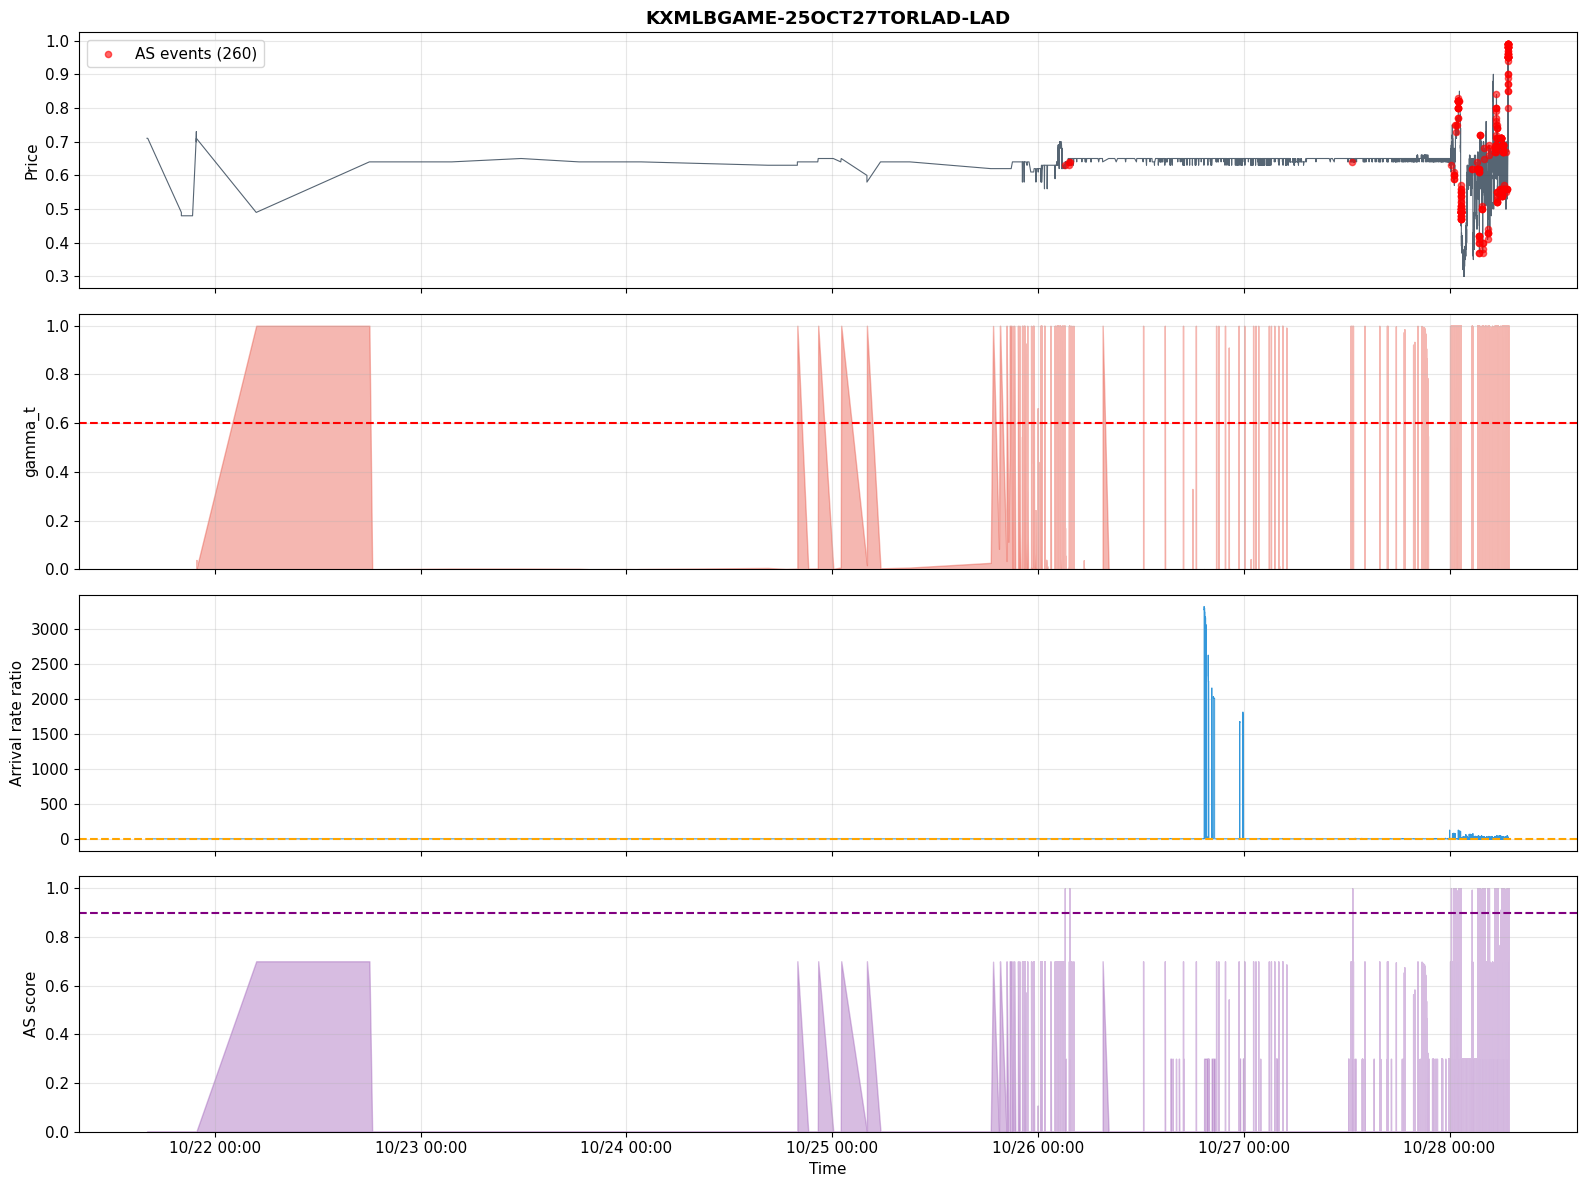

In [10]:
if all_as:
    showcase_tkr = max(all_as.keys(), key=lambda k: len(all_as[k].prices))
    ar = all_as[showcase_tkr]
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    ts = pd.to_datetime(ar.timestamps)

    axes[0].plot(ts, ar.prices, color="#2c3e50", lw=0.8, alpha=0.8)
    em = ar.as_score > 0.9
    axes[0].scatter(ts[em], ar.prices[em], color="red", s=20, alpha=0.6, zorder=5, label=f"AS events ({em.sum()})")
    axes[0].set_ylabel("Price"); axes[0].set_title(showcase_tkr, fontweight="bold"); axes[0].legend()

    axes[1].fill_between(ts, 0, ar.gamma, color="#e74c3c", alpha=0.4)
    axes[1].axhline(0.6, color="red", ls="--"); axes[1].set_ylabel("gamma_t"); axes[1].set_ylim(0, 1.05)

    axes[2].plot(ts, ar.arrival_rate_ratio, color="#3498db", lw=0.7)
    axes[2].axhline(3.0, color="orange", ls="--"); axes[2].set_ylabel("Arrival rate ratio")

    axes[3].fill_between(ts, 0, ar.as_score, color="#9b59b6", alpha=0.4)
    axes[3].axhline(0.9, color="purple", ls="--"); axes[3].set_ylabel("AS score"); axes[3].set_xlabel("Time")
    axes[3].set_ylim(0, 1.05)

    for a in axes:
        a.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    plt.tight_layout()
    os.makedirs("../figures", exist_ok=True)
    plt.savefig("../figures/sports_as_showcase.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Fill Toxicity Validation

In [11]:
if all_as:
    print("Fill Toxicity — Flagged vs Unflagged")
    print("=" * 90)
    for tkr in list(all_as.keys())[:8]:
        ar = all_as[tkr]
        tox = analyse_fill_toxicity(ar, mtm_horizons=[10, 30, 60, 120])
        if tox.empty: continue
        print(f"\n{tkr} ({len(ar.prices):,} trades)")
        print(tox.to_string(index=False, float_format="%.4f"))

Fill Toxicity — Flagged vs Unflagged

KXMLBGAME-25OCT27TORLAD-LAD (52,362 trades)
 horizon_trades  n_flagged  n_unflagged  mean_move_flagged  mean_move_unflagged  ratio  t_stat  p_value
             10        310        14533             0.0236               0.0119 1.9791 12.0692   0.0000
             30        310        14533             0.0286               0.0165 1.7306  8.7228   0.0000
             60        310        14533             0.0313               0.0218 1.4397  5.5632   0.0000
            120        310        14533             0.0370               0.0307 1.2072  2.8731   0.0020

KXMLBGAME-25OCT27TORLAD-TOR (44,406 trades)
 horizon_trades  n_flagged  n_unflagged  mean_move_flagged  mean_move_unflagged  ratio  t_stat  p_value
             10        514        14529             0.0262               0.0121 2.1606 18.0353   0.0000
             30        514        14529             0.0336               0.0167 2.0167 15.3917   0.0000
             60        514        14529  

## 5. Market-Making Backtest

In [12]:
if all_as:
    comparisons = compare_all_tickers(all_as, as_threshold=0.9, half_spread_cents=2.0, mtm_horizon_trades=60)
    comp_df = pd.DataFrame([c.summary for c in comparisons.values()]).sort_values("naive_pnl_c", ascending=False)

    print("Naive vs AS-Informed (tau=0.9)")
    print("=" * 100)
    print(comp_df.to_string(index=False, float_format="%.2f"))

    nt = comp_df.naive_pnl_c.sum(); it = comp_df.informed_pnl_c.sum()
    print(f"\nNaive total: {nt:.1f}c | Informed total: {it:.1f}c | Delta: {it-nt:+.1f}c")
    improved = sum(1 for c in comparisons.values() if c.pnl_improvement > 0)
    print(f"Improved: {improved}/{len(comparisons)} tickers")

[2026-03-03 03:52:25 UTC] [INFO] tauroi.mm_backtest — Comparison KXMLBGAME-25OCT27TORLAD-LAD: naive=11819.0c (5321 fills) | informed=11848.3c (5261 fills) | improvement=29.3c | avoided=60 toxic fills
[2026-03-03 03:52:25 UTC] [INFO] tauroi.mm_backtest — Comparison KXMLBGAME-25OCT27TORLAD-TOR: naive=10906.3c (5010 fills) | informed=10787.6c (4913 fills) | improvement=-118.8c | avoided=97 toxic fills
[2026-03-03 03:52:25 UTC] [INFO] tauroi.mm_backtest — Comparison KXMLBGAME-25OCT24LADTOR-LAD: naive=2826.4c (1189 fills) | informed=2814.6c (1186 fills) | improvement=-11.8c | avoided=3 toxic fills
[2026-03-03 03:52:25 UTC] [INFO] tauroi.mm_backtest — Comparison KXMLBGAME-25OCT28TORLAD-LAD: naive=2213.8c (994 fills) | informed=2105.4c (975 fills) | improvement=-108.4c | avoided=19 toxic fills
[2026-03-03 03:52:26 UTC] [INFO] tauroi.mm_backtest — Comparison KXMLBGAME-25OCT31LADTOR-TOR: naive=3206.3c (1567 fills) | informed=2902.2c (1549 fills) | improvement=-304.1c | avoided=18 toxic fills
[2

## 6. Threshold Sweep

Threshold sweep: KXMLBGAME-25OCT27TORLAD-LAD
 threshold    strategy  n_fills  n_pulled  net_pnl_c  pnl_per_fill_c  win_rate  gross_spread_c  mtm_pnl_c  fees_c
      0.00       naive     5321         0   11819.01            2.22      0.85        10642.00    3322.00 2144.99
      0.10 as_informed     4397      6320   10433.06            2.37      0.87         8794.00    3418.00 1778.94
      0.20 as_informed     4398      6309   10433.70            2.37      0.87         8796.00    3417.00 1779.30
      0.30 as_informed     4401      6297   10443.70            2.37      0.87         8802.00    3422.00 1780.30
      0.40 as_informed     5188      1099   11710.53            2.26      0.85        10376.00    3432.00 2097.47
      0.50 as_informed     5191      1085   11696.32            2.25      0.85        10382.00    3413.00 2098.68
      0.60 as_informed     5197      1054   11705.94            2.25      0.85        10394.00    3413.00 2101.06
      0.70 as_informed     5258       283  

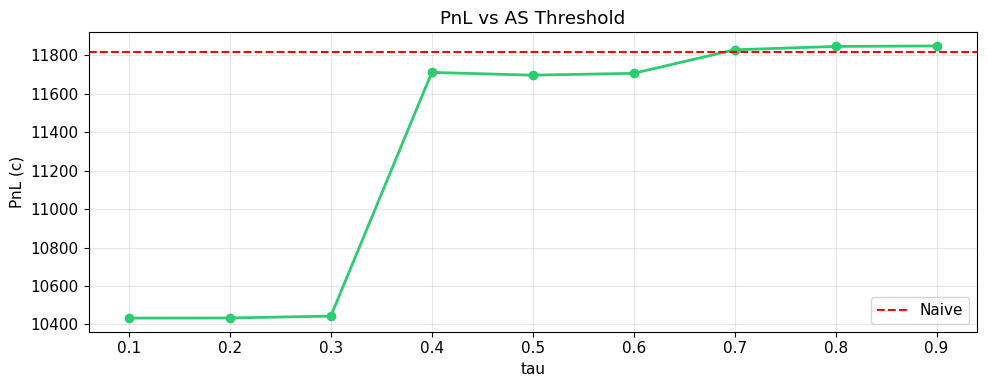

In [13]:
if all_as:
    sweep_tkr = max(all_as.keys(), key=lambda k: len(all_as[k].prices))
    sweep_df = sweep_thresholds(all_as[sweep_tkr], mtm_horizon_trades=60)
    print(f"Threshold sweep: {sweep_tkr}")
    print(sweep_df.to_string(index=False, float_format="%.2f"))

    fig, ax = plt.subplots(figsize=(10, 4))
    inf = sweep_df[sweep_df.strategy == "as_informed"]
    ax.plot(inf.threshold, inf.net_pnl_c, "o-", color="#2ecc71", lw=2)
    ax.axhline(sweep_df.iloc[0].net_pnl_c, color="red", ls="--", label="Naive")
    ax.set_xlabel("tau"); ax.set_ylabel("PnL (c)"); ax.set_title("PnL vs AS Threshold"); ax.legend()
    plt.tight_layout()
    plt.savefig("../figures/sports_threshold_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Summary

In [14]:
if all_as and comparisons:
    print("=" * 70)
    print("ADVERSE SELECTION — MLB GAME MARKETS SUMMARY")
    print("=" * 70)
    tt = sum(len(ar.prices) for ar in all_as.values())
    te = sum((ar.as_score > 0.9).sum() for ar in all_as.values())
    print(f"Tickers: {len(all_as)} | Trades: {tt:,} | AS events: {te:,} ({te/tt*100:.1f}%)")
    nt = sum(c.naive.net_pnl for c in comparisons.values())
    it = sum(c.informed.net_pnl for c in comparisons.values())
    print(f"Backtest (tau=0.9): Naive={nt:.1f}c Informed={it:.1f}c Delta={it-nt:+.1f}c")
    print(f"Improved: {sum(1 for c in comparisons.values() if c.pnl_improvement > 0)}/{len(comparisons)} tickers")
    print("=" * 70)

ADVERSE SELECTION — MLB GAME MARKETS SUMMARY
Tickers: 40 | Trades: 714,486 | AS events: 8,840 (1.2%)
Backtest (tau=0.9): Naive=105549.2c Informed=104237.3c Delta=-1311.8c
Improved: 8/40 tickers
